In [1]:
import mediapipe as mp
import cv2
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Drawing helpers
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

### 1. Train Model

#### 1.1. Describe data and split dataset

In [2]:
def rescale_frame(frame, percent=50):
    '''
    Rescale a frame to a certain percentage compare to its original frame
    '''
    width = int(frame.shape[1] * percent/ 100)
    height = int(frame.shape[0] * percent/ 100)
    dim = (width, height)
    return cv2.resize(frame, dim, interpolation = cv2.INTER_AREA)


def describe_dataset(dataset_path: str):
    '''
    Describe dataset
    '''

    data = pd.read_csv(dataset_path)
    print(f"Headers: {list(data.columns.values)}")
    print(f'Number of rows: {data.shape[0]} \nNumber of columns: {data.shape[1]}\n')
    print(f"Labels: \n{data['label'].value_counts()}\n")
    print(f"Missing values: {data.isnull().values.any()}\n")
    
    duplicate = data[data.duplicated()]
    print(f"Duplicate Rows : {len(duplicate.sum(axis=1))}")

    return data


def round_up_metric_results(results) -> list:
    '''Round up metrics results such as precision score, recall score, ...'''
    return list(map(lambda el: round(el, 3), results))

In [19]:
# df = describe_dataset("./train.csv")
# df = describe_dataset("train_augmented.csv")
# df = describe_dataset("train_augmented.csv")
df = describe_dataset("mountain_with_angles.csv")
# df.loc[df["label"] == "c", "label"] = 0
# df.loc[df["label"] == "i", "label"] = 1
# df.loc[df["label"] == "H", "label"] = 2
# df.loc[df["label"] == "L", "label"] = 3

label_map = {
    'c': 0,                  # correct pose
    'feet_too_close': 1,     # stance too narrow
    'arms_dropped': 2,       # arms hanging too low
    'shoulders_raised': 3,   # shoulders tense/raised
    'leaning_forward': 4,    # torso leaning forward
    'leaning_back': 5,       # torso leaning backward
    'head_tilted': 6         # head tilted instead of neutral
}


df["label"] = df["label"].map(label_map)
reverse_map = {v: k for k, v in label_map.items()}



df.head(3)

Headers: ['label', 'nose_x', 'nose_y', 'nose_z', 'nose_v', 'left_ear_x', 'left_ear_y', 'left_ear_z', 'left_ear_v', 'right_ear_x', 'right_ear_y', 'right_ear_z', 'right_ear_v', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_shoulder_v', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_shoulder_v', 'left_elbow_x', 'left_elbow_y', 'left_elbow_z', 'left_elbow_v', 'right_elbow_x', 'right_elbow_y', 'right_elbow_z', 'right_elbow_v', 'left_wrist_x', 'left_wrist_y', 'left_wrist_z', 'left_wrist_v', 'right_wrist_x', 'right_wrist_y', 'right_wrist_z', 'right_wrist_v', 'left_index_x', 'left_index_y', 'left_index_z', 'left_index_v', 'right_index_x', 'right_index_y', 'right_index_z', 'right_index_v', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_hip_v', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_hip_v', 'left_knee_x', 'left_knee_y', 'left_knee_z', 'left_knee_v', 'right_knee_x', 'right_knee_y', 'right_knee_z', 'right_knee_v', 'left_ankle_x', 'left_ankle_y', '

,label,nose_x,nose_y,nose_z,nose_v,left_ear_x,left_ear_y,left_ear_z,left_ear_v,right_ear_x,...,right_heel_z,right_heel_v,left_shoulder_angle,left_elbow_angle,left_hip_angle,left_knee_angle,right_shoulder_angle,right_elbow_angle,right_hip_angle,right_knee_angle
0,0,0.577521,0.172172,-0.766958,0.999985,0.621025,0.166568,-0.446601,0.999918,0.521230,...,0.594650,0.791788,15.697065,62.076693,140.259940,112.136163,11.678856,69.902100,148.057013,124.457231
1,0,0.516222,0.182567,-0.848024,0.999997,0.575722,0.175204,-0.556826,0.999970,0.469550,...,0.529114,0.867764,18.288993,72.389458,137.341393,122.714678,32.712405,87.730715,145.647685,130.107802
2,0,0.511727,0.252431,-0.285891,0.999978,0.551945,0.249360,-0.135423,0.999814,0.467546,...,0.285243,0.864618,30.815747,107.678837,142.240300,99.366780,32.851357,104.507249,151.973286,115.536426


In [20]:
# Extract features and class
X = df.drop("label", axis=1)
y = df["label"].astype("int")

In [ ]:
# sc = StandardScaler()
# # X = pd.DataFrame(sc.fit_transform(X))
# X = pd.DataFrame(sc.fit_transform(X), columns=X.columns, index=X.index)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y)
y_test.head(3)

154     6
2359    3
6791    3
Name: label, dtype: int32

In [6]:
import xgboost as xgb

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])


In [23]:
param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.2, 0.3]
}

In [24]:
from sklearn.model_selection import  StratifiedKFold, RandomizedSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [25]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=skf,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

In [26]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='loglos...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__gamma': [0, 0.1, 0.2, 0.3],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__n_estimators': [100, 200, 300,
                                                                400],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=1)

In [27]:
print("===== Hyperparameter Tuning Results =====")

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(random_search.best_score_)

cv_mean = random_search.cv_results_['mean_test_score'][random_search.best_index_]
cv_std = random_search.cv_results_['std_test_score'][random_search.best_index_]

print("\nCV Mean Accuracy:", cv_mean)
print("CV Standard Deviation:", cv_std)


===== Hyperparameter Tuning Results =====

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__gamma': 0, 'model__colsample_bytree': 1.0}

Best Cross-Validation Accuracy:
0.9942282315618206

CV Mean Accuracy: 0.9942282315618206
CV Standard Deviation: 0.0018799274694553812


In [28]:
best_model = random_search.best_estimator_

# best_model.fit(X_train, y_train)


In [29]:
# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', best_model)
# ])

# Fit pipeline on training data
# pipeline.fit(X_train, y_train)
pipeline = random_search.best_estimator_


In [30]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    pipeline,
    X_train, y_train,
    cv=skf,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

print("\n===== Cross-Validation Results =====")
print("Train Accuracy:", cv_results['train_accuracy'].mean())
print("Validation Accuracy:", cv_results['test_accuracy'].mean())
print("Mean Precision:", cv_results['test_precision_macro'].mean())
print("Mean Recall:", cv_results['test_recall_macro'].mean())
print("Mean F1 Score:", cv_results['test_f1_macro'].mean())
print("Std Accuracy:", cv_results['test_accuracy'].std())



===== Cross-Validation Results =====
Train Accuracy: 1.0
Validation Accuracy: 0.9935687097151595
Mean Precision: 0.9937616354090709
Mean Recall: 0.9935666353445903
Mean F1 Score: 0.9935961741343574
Std Accuracy: 0.0019083011969235856


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = pipeline.predict(X_test)

print("\n===== Test Set Evaluation =====")
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



===== Test Set Evaluation =====
Test Accuracy: 0.996704021094265

Confusion Matrix:
[[216   1   0   0   0   0   0]
 [  1 215   0   0   0   0   0]
 [  0   0 216   0   0   0   0]
 [  2   0   0 215   0   0   0]
 [  0   0   0   0 217   0   0]
 [  0   0   0   0   0 217   0]
 [  1   0   0   0   0   0 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       217
           1       1.00      1.00      1.00       216
           2       1.00      1.00      1.00       216
           3       1.00      0.99      1.00       217
           4       1.00      1.00      1.00       217
           5       1.00      1.00      1.00       217
           6       1.00      1.00      1.00       217

    accuracy                           1.00      1517
   macro avg       1.00      1.00      1.00      1517
weighted avg       1.00      1.00      1.00      1517



In [31]:
import pandas as pd

cv_results_df = pd.DataFrame(random_search.cv_results_)

print("\nTop 5 Hyperparameter Combinations:")
print(
    cv_results_df[['mean_test_score', 'std_test_score', 'params']]
    .sort_values(by='mean_test_score', ascending=False)
    .head()
)



Top 5 Hyperparameter Combinations:
    mean_test_score  std_test_score  \
17         0.994228        0.001880   
5          0.994063        0.002239   
1          0.993898        0.001777   
0          0.993403        0.001566   
4          0.993239        0.001418   

                                               params  
17  {'model__subsample': 0.8, 'model__n_estimators...  
5   {'model__subsample': 0.7, 'model__n_estimators...  
1   {'model__subsample': 0.7, 'model__n_estimators...  
0   {'model__subsample': 0.7, 'model__n_estimators...  
4   {'model__subsample': 0.9, 'model__n_estimators...  


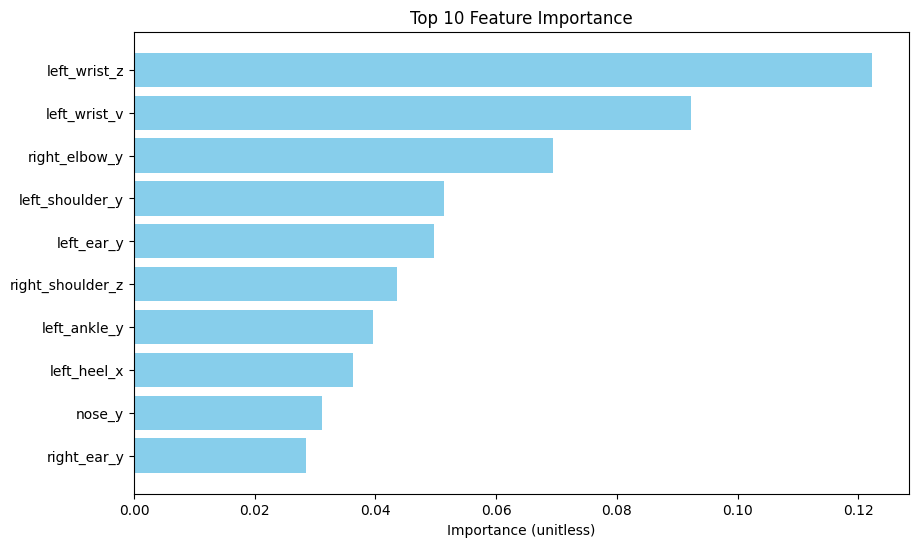

In [18]:

import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': pipeline.named_steps['model'].feature_importances_
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'].tail(10), feat_imp['importance'].tail(10), color='skyblue')
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance (unitless)")
plt.show()



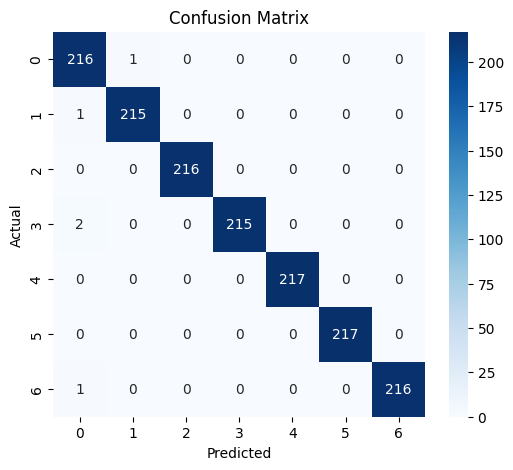

In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


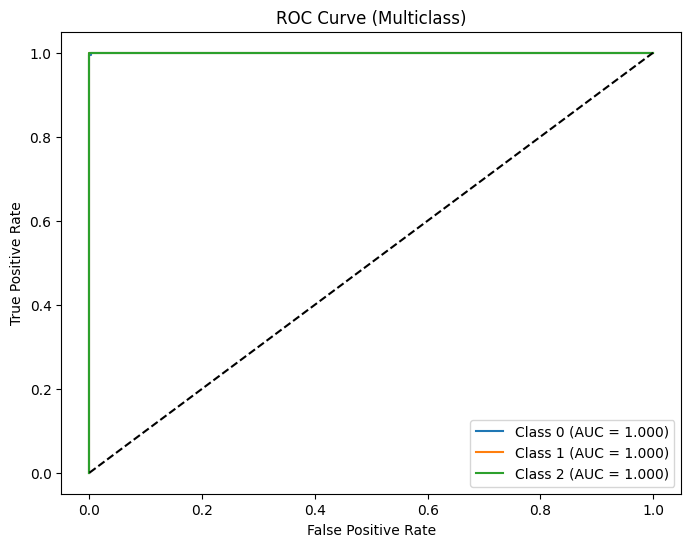

In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize y_test for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Use the pipeline for predict_proba (handles scaling automatically)
y_prob = pipeline.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass)")
plt.legend(loc="lower right")
plt.show()


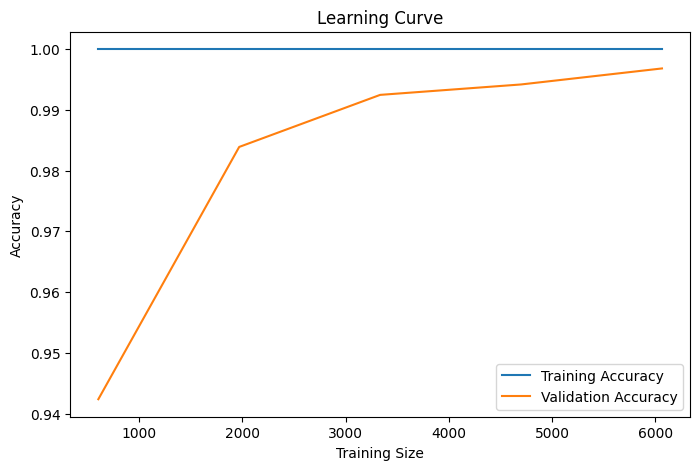

In [34]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


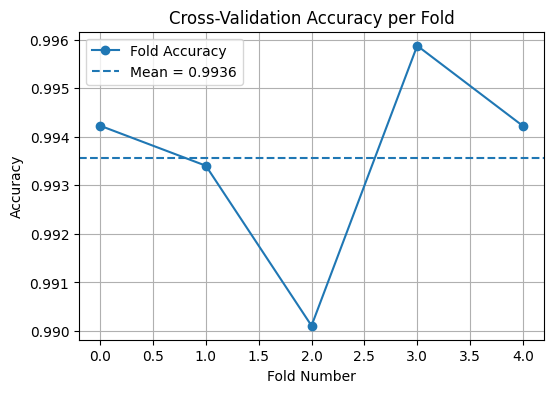

In [35]:
import matplotlib.pyplot as plt

# Extract test accuracy from cross_validate results
cv_scores = cv_results['test_accuracy']

mean_score = cv_scores.mean()

plt.figure(figsize=(6,4))
plt.plot(cv_scores, marker='o', label="Fold Accuracy")
plt.axhline(mean_score, linestyle='--', label=f"Mean = {mean_score:.4f}")
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
with open("./model/plank_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

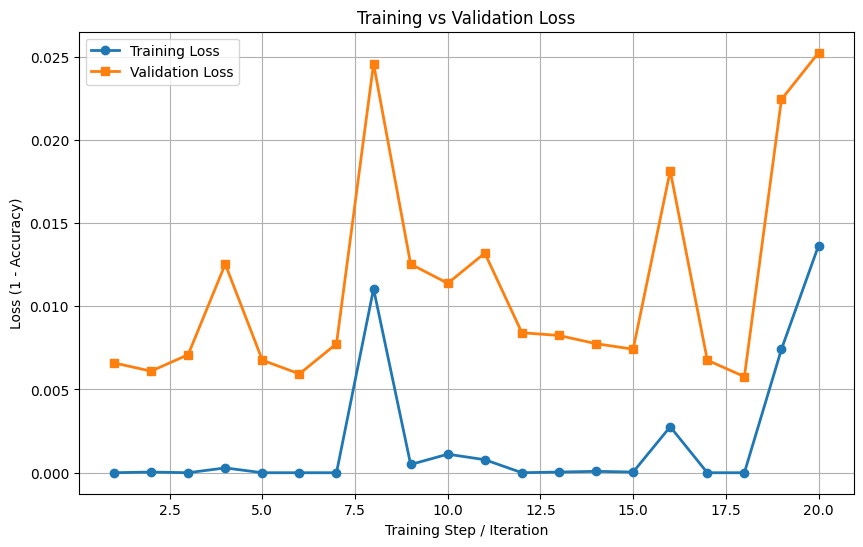

#### 1.2. Train model using Scikit-Learn and train set evaluation

In [7]:
algorithms =[("LR", LogisticRegression()),
         ("SVC", SVC(probability=True)),
         ('KNN',KNeighborsClassifier()),
         ("DTC", DecisionTreeClassifier()),
         ("SGDC", CalibratedClassifierCV(SGDClassifier())),
         ("NB", GaussianNB()),
         ('RF', RandomForestClassifier()),]

models = {}
final_results = []

for name, model in algorithms:
    trained_model = model.fit(X_train, y_train)
    models[name] = trained_model

    # Evaluate model
    model_results = model.predict(X_test)

    p_score = precision_score(y_test, model_results, average=None, labels=[0, 1, 2,3,4,5,6])
    a_score = accuracy_score(y_test, model_results)
    r_score = recall_score(y_test, model_results, average=None, labels=[0, 1, 2,3,4,5,6])
    f1_score_result = f1_score(y_test, model_results, average=None, labels=[0, 1, 2,3,4,5,6])
    cm = confusion_matrix(y_test, model_results, labels=[0, 1, 2,3,4,5,6])
    final_results.append(( name,  round_up_metric_results(p_score), a_score, round_up_metric_results(r_score), round_up_metric_results(f1_score_result), cm))


In [9]:
# Sort results by F1 score
final_results.sort(key=lambda k: sum(k[4]), reverse=True)

pd.DataFrame(final_results, columns=["Model", "Precision Score", "Accuracy score", "Recall Score", "F1 score", "Confusion Matrix"])

,Model,Precision Score,Accuracy score,Recall Score,F1 score,Confusion Matrix
0,RF,"[0.985, 0.995, 1.0, 0.996, 0.995, 1.0, 0.996]",0.995386,"[0.985, 0.991, 1.0, 1.0, 1.0, 0.995, 0.996]","[0.985, 0.993, 1.0, 0.998, 0.998, 0.998, 0.996]","[[194, 1, 0, 0, 1, 0, 1], [2, 221, 0, 0, 0, 0,..."
1,LR,"[0.97, 0.995, 1.0, 1.0, 1.0, 1.0, 1.0]",0.995386,"[0.995, 0.987, 1.0, 1.0, 0.995, 0.995, 0.996]","[0.982, 0.991, 1.0, 1.0, 0.998, 0.998, 0.998]","[[196, 1, 0, 0, 0, 0, 0], [3, 220, 0, 0, 0, 0,..."
2,SGDC,"[0.98, 0.982, 1.0, 1.0, 1.0, 1.0, 1.0]",0.994726,"[0.985, 0.991, 1.0, 0.995, 1.0, 0.991, 1.0]","[0.982, 0.987, 1.0, 0.998, 1.0, 0.995, 1.0]","[[194, 3, 0, 0, 0, 0, 0], [2, 221, 0, 0, 0, 0,..."
3,SVC,"[0.87, 0.995, 1.0, 0.978, 0.995, 1.0, 0.986]",0.974291,"[0.985, 0.969, 1.0, 0.986, 0.995, 0.986, 0.906]","[0.924, 0.982, 1.0, 0.982, 0.995, 0.993, 0.945]","[[194, 0, 0, 0, 1, 0, 2], [6, 216, 0, 1, 0, 0,..."
4,DTC,"[0.912, 1.0, 0.995, 0.956, 0.986, 0.986, 0.966]",0.971655,"[0.944, 0.982, 0.986, 0.982, 0.982, 0.967, 0.957]","[0.928, 0.991, 0.99, 0.969, 0.984, 0.976, 0.962]","[[186, 0, 1, 4, 2, 0, 4], [2, 219, 0, 1, 0, 0,..."
5,KNN,"[0.689, 0.962, 1.0, 0.915, 1.0, 0.99, 0.932]",0.916941,"[0.944, 0.906, 0.981, 0.923, 0.982, 0.939, 0.762]","[0.797, 0.933, 0.99, 0.919, 0.991, 0.964, 0.838]","[[186, 3, 0, 3, 0, 0, 5], [15, 202, 0, 2, 0, 1..."
6,NB,"[0.511, 0.738, 0.905, 0.705, 0.858, 0.817, 0.451]",0.696111,"[0.122, 0.695, 0.91, 0.658, 0.835, 0.778, 0.821]","[0.197, 0.716, 0.907, 0.681, 0.847, 0.797, 0.582]","[[24, 21, 9, 19, 9, 9, 106], [7, 155, 5, 7, 10..."


#### 1.3. Test set evaluation

In [ ]:
# test_df = describe_dataset("./test.csv")
test_df = describe_dataset("test.csv")
test_df = test_df.sample(frac=1).reset_index(drop=True)

test_df.loc[test_df["label"] == "C", "label"] = 0
test_df.loc[test_df["label"] == "H", "label"] = 1
test_df.loc[test_df["label"] == "L", "label"] = 2

test_x = test_df.drop("label", axis=1)
test_y = test_df["label"].astype("int")

test_x = pd.DataFrame(sc.transform(test_x))

In [ ]:
# Evaluate models on the test sets
testset_final_results = []

for name, model in models.items():
    # Evaluate model
    model_results = model.predict(test_x)

    p_score = precision_score(test_y, model_results, average=None, labels=[0, 1, 2])
    a_score = accuracy_score(test_y, model_results)
    r_score = recall_score(test_y, model_results, average=None, labels=[0, 1, 2])
    f1_score_result = f1_score(test_y, model_results, average=None, labels=[0, 1, 2])
    cm = confusion_matrix(test_y, model_results, labels=[0, 1, 2])
    testset_final_results.append(( name,  round_up_metric_results(p_score), a_score, round_up_metric_results(r_score), round_up_metric_results(f1_score_result), cm ))


testset_final_results.sort(key=lambda k: sum(k[4]), reverse=True)
pd.DataFrame(testset_final_results, columns=["Model", "Precision Score", "Accuracy score", "Recall Score", "F1 score", "Confusion Matrix"])

In [9]:
# Evaluate LR model on test set
lr_model = models["LR"]
lr_predictions = lr_model.predict(X_test)

lr_precision = precision_score(y_test, lr_predictions, average=None, labels=[0, 1, 2,3,4,5,6,7])
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions, average=None, labels=[0, 1, 2,3,4,5,6,7])
lr_f1 = f1_score(y_test, lr_predictions, average=None, labels=[0, 1, 2,3,4,5,6,7])

print("LR Precision:", round_up_metric_results(lr_precision))
print("LR Accuracy:", lr_accuracy)
print("LR Recall:", round_up_metric_results(lr_recall))
print("LR F1 Score:", round_up_metric_results(lr_f1))

LR Precision: [0.97, 0.995, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
LR Accuracy: 0.995385629531971
LR Recall: [0.995, 0.987, 1.0, 1.0, 0.995, 0.995, 0.996, 0.0]
LR F1 Score: [0.982, 0.991, 1.0, 1.0, 0.998, 0.998, 0.998, 0.0]


#### 1.4. Dumped model and input scaler using pickle

According to the evaluations, there are multiple good models at the moment, therefore, the best models are LR and Ridge.

In [10]:
with open("./model/all_sklearn.pkl", "wb") as f:
    pickle.dump(models, f)

In [11]:
with open("./model/LR_model.pkl", "wb") as f:
    pickle.dump(models["LR"], f)

In [12]:
with open("./model/SVC_model.pkl", "wb") as f:
    pickle.dump(models["SVC"], f)

In [13]:
# Dump input scaler
with open("./model/input_scaler.pkl", "wb") as f:
    pickle.dump(sc, f)